## Total points = 64

In [1]:
pts1 = 10
pts2 = 6 + 6 + 8 + 6 + 8
pts3 = 4 + 4 + 2 + 10
print(pts1, pts2, pts3, pts1 + pts2 + pts3)

10 34 20 64


## Problem 1: install Python, numpy, matplotlib, astropy (10 pts)

### full credit if the rest of the assignment is attempted

<font color='red'>red text</font>

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import astropy.units as u
import astropy.constants as c

## Problem 2a: For Beta Pictoris and Gaia DR3 4373465352415301632, gather the mean values for the parallax, apparent brightness in Gaia's G filter, and the mean effective temperature and report them as your answer (6pts)

### one point for each value
### -0.5 for each missing unit

In [3]:
beta_pic_parallax = 50.9307 * u.mas
beta_pic_G = 3.8232
beta_pic_teff = 7938 * u.K

In [4]:
GDR3_star_parallax = 2.07 * u.mas
GDR3_star_G = 13.772
GDR3_star_teff = 5396 * u.K

### Problem 2b:  calculate the apparent bolometric magnitude for each star (6 pts)

#### 2pts per bolometric magnitude
#### 2pts for description

In [5]:
beta_pic_BC = 0.0172
GDR3_star_BC = 0.0035

#### M$_{\rm{abs}}$ = M$_{\rm{app}}$ + BC

In [6]:
beta_pic_bol_app = beta_pic_G + beta_pic_BC
GDR3_star_bol_app = GDR3_star_G + GDR3_star_BC

In [7]:
print(beta_pic_bol_app)
print(GDR3_star_bol_app)

3.8404
13.775500000000001


The spectral class of the Gaia DR3 star is G type, which is square in the Gaia G filter, while Beta Pictoris is hotter (an A spectral type), so the bolometric correction is larger because less flux is emitted in the G filter temperature range. 

### Problem 2c: First estimate the absolute bolometric magnitude of each star, using the estimated distance. Then, using the absolute bolometric magnitude of the Sun, calculate the bolometric luminosity of both Beta Pictoris and Gaia DR3 4373465352415301632. (8 pts)

### 2pts per absolute bolometric magnitude, 2pts per luminosity
### -0.5 pts for each missing unit

#### (distance/parsec) = (arcsec/parallax), but we can also use astropy equivalincies!

In [8]:
beta_pic_dist = beta_pic_parallax.to(u.pc, equivalencies=u.parallax())
GDR3_star_dist = GDR3_star_parallax.to(u.pc, equivalencies=u.parallax())

print(beta_pic_dist)
print(GDR3_star_dist)

19.634522989081237 pc
483.0917874396135 pc


#### $M_{\rm{app}} - M_{\rm{abs}} = 5 \times \log_{10}(d/10\,\rm{pc})$

In [9]:
beta_pic_m_abs_bol = beta_pic_bol_app - 5 * np.log10(beta_pic_dist/(10*u.pc))
GDR3_star_m_abs_bol = GDR3_star_bol_app - 5 * np.log10(GDR3_star_dist/(10*u.pc))

print(beta_pic_m_abs_bol)
print(GDR3_star_m_abs_bol)

2.3752982261634523
5.3553517272845905


#### $M_{\rm{abs,\odot,bol}} = 4.75$
#### $M_{\rm{abs,\star,bol}} = M_{\rm{abs,\odot,bol}} - 2.5 \log_{10}\big(\frac{L_{\star}}{L_{\rm{odot}}}\big)$
#### convert to $L_{\star}$
#### $M_{\rm{abs,\star,bol}} - M_{\rm{abs,\odot,bol}}$ = $- 2.5 \log_{10}\big(\frac{L_{\star}}{L_{\rm{odot}}}\big)$
#### $10^{-(M_{\rm{abs,\star,bol}} - M_{\rm{abs,\odot,bol}})/2.5}$ = $\big(\frac{L_{\star}}{L_{\rm{odot}}}\big)$
#### $L_{\star} = L_{\rm{odot}}\times 10^{-(M_{\rm{abs,\star,bol}} - M_{\rm{abs,\odot,bol}})/2.5}$

In [10]:
M_abs_sun = 4.75
beta_pic_lum_bol = 10**((M_abs_sun - beta_pic_m_abs_bol)/2.5) * u.Lsun
GDR3_star_lum_bol = 10**((M_abs_sun - GDR3_star_m_abs_bol)/2.5) * u.Lsun

print(beta_pic_lum_bol)
print(GDR3_star_lum_bol)

8.9100616611048 solLum
0.57261050216015 solLum


### Problem 2d: Calculate the radius of both Beta Pictoris and Gaia DR3 4373465352415301632. How do they compare to the Sun's radius? (6 pts)

### 2 pts per radius, 2pts for comparison
### -0.5 per missing unit

### $L = 4\pi R^2\sigma_{B}T_{\rm{eff}}^4$
### $R^2 = L/(4\pi \sigma_{B}T_{\rm{eff}}^4)$

In [11]:
beta_pic_rad = ((beta_pic_lum_bol/(4 * np.pi * c.sigma_sb * beta_pic_teff**4))**0.5).to(u.Rsun)
GDR3_star_rad = ((GDR3_star_lum_bol/(4 * np.pi * c.sigma_sb * GDR3_star_teff**4))**0.5).to(u.Rsun)

print(beta_pic_rad)
print(GDR3_star_rad)

1.578233750371186 solRad
0.8658425677894298 solRad


DR3 star is close to solar while Beta Pic is larger

### Problem 2e: Use the M--L relation to estimate the mass of both Beta Pictoris and Gaia DR3 4373465352415301632; compare to other methods; percent difference (8 pts)

### 2 pts per estimated mass; 2 pts for comparison; 2 pts per percent difference

#### M--L is: $(M/M_{\odot})^{3.8} = (L/L_{\odot})$ so
#### $M/M_{\odot} = (L/L_{\odot})^{1/3.8}$

In [12]:
beta_pic_mass = (beta_pic_lum_bol/u.Lsun)**(1/3.8) * u.Msun
GDR3_star_mass = (GDR3_star_lum_bol/u.Lsun)**(1/3.8) * u.Msun

print(beta_pic_mass)
print(GDR3_star_mass)

1.7781508748237425 solMass
0.8635326554599483 solMass


In [13]:
beta_pic_mass_spec = 1.75 * u.Msun
GDR3_star_mass_spec = 0.93 * u.Msun

The mass estimate is much closer for Beta Pictoris than for the Gaia star but they are qualitatively the same

In [14]:
beta_pic_perc_diff = np.abs((beta_pic_mass - beta_pic_mass_spec))/(beta_pic_mass + beta_pic_mass_spec)/2 * 100
GDR3_star_perc_diff = np.abs((GDR3_star_mass - GDR3_star_mass_spec))/(GDR3_star_mass + GDR3_star_mass_spec)/2 * 100

print(beta_pic_perc_diff)
print(GDR3_star_perc_diff)

0.3989465845214003
1.8529728002919001


### Problem 3a: Try printing the results table r, which shows each star as a separate row. How does the requirement for parallax > 0.2 mas influence the distance of the stars in our table? (4pts)

### 2pts for printing, 2 pts for statement of relation between parallax and distance

In [15]:
from astroquery.gaia import Gaia

In [16]:
gaiadr3_table = Gaia.load_table('gaiadr3.gaia_source')

Retrieving table 'gaiadr3.gaia_source'


In [17]:
job = Gaia.launch_job("select top 5000 "
                      "source_id, phot_g_mean_mag, "
                      "phot_bp_mean_mag, phot_rp_mean_mag, parallax "
                      "from gaiadr3.gaia_source where parallax_over_error > 20 and parallax > 0.2")
r = job.get_results()

In [18]:
print(r)

     source_id      phot_g_mean_mag ... phot_rp_mean_mag      parallax     
                          mag       ...       mag               mas        
------------------- --------------- ... ---------------- ------------------
3444412829062210560       15.203718 ...        14.400867 0.6390254343352071
6369569510812755328       18.305372 ...        16.988579  3.100122673346884
5902559231207979008       17.233137 ...        16.245045 1.6630571269187417
5822406207933947264      15.0276575 ...         14.57748 0.4578570640490629
2060421091813445504       15.539901 ...        14.751871 0.8875493303315524
1130547237552438272       16.076492 ...        15.475897 0.6570312533695974
                ...             ... ...              ...                ...
3049744783839836800       13.424101 ...        12.711549 0.3147633868540612
5902087643806938624       14.423031 ...        13.863464 0.6050284455022481
4085567234951470592       15.013269 ...        14.374951  0.593670214313298
447129261279

In [19]:
print(r['parallax'].to(u.pc, equivalencies=u.parallax()).max())
print(1/(0.0002))

4839.62793294812 pc
5000.0


#### The maximum distance in parsecs is 1/(0.0002 as) = 5000 pc. 

### Problem 3b: plot a scatter plot that shows the color-magnitude diagram which contains the apparent G magnitude on the y axis and the BP - RP magnitude on the x axis for each source. Be sure to label each axis! (4pts)

### 4 pts for the figure
### 1 pt per missing label

(22.0, 8.0)

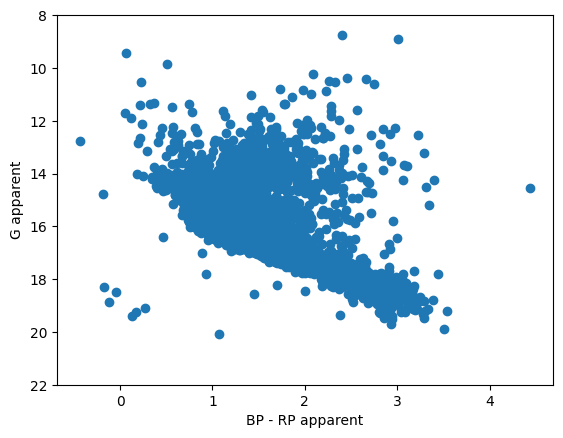

In [20]:
plt.scatter(r['phot_bp_mean_mag'] - r['phot_rp_mean_mag'], r['phot_g_mean_mag'])

plt.ylabel('G apparent')
plt.xlabel('BP - RP apparent')
plt.ylim(22, 8)

### Problem 3c: Convert the parallax to distance and store the distance values in a new column in your results table (2pts)

In [21]:
r['dist'] = r['parallax'].to(u.pc, equivalencies=u.parallax())

### Problem 3d: Use distance modulus to get absolute magnitudes and make absolute CMD (10pts)

### 2 pts per aboslute magnitude
### 4 pts for figure
### -1pt per missing axis label
### -1pt if y axis isn't upside down

In [22]:
r['G_abs'] = r['phot_g_mean_mag'].value - 5 * np.log10(r['dist']/(10*u.pc))
r['BP_abs'] = r['phot_bp_mean_mag'].value - 5 * np.log10(r['dist']/(10*u.pc))
r['RP_abs'] = r['phot_rp_mean_mag'].value - 5 * np.log10(r['dist']/(10*u.pc))

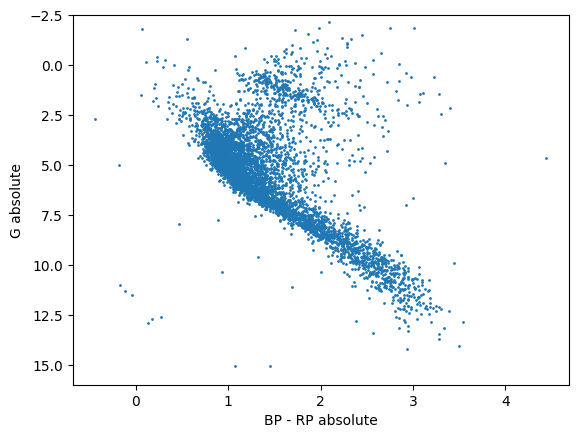

In [23]:
plt.scatter(r['BP_abs'] - r['RP_abs'], r['G_abs'], s=1)

plt.ylabel('G absolute')
plt.xlabel('BP - RP absolute')
plt.ylim(16, -2.5);